# Training RL agent # 

Here, we will breakdown how we are able to use SB3 library to train a RL agent 

In [1]:
%pip install tensorboard
%pip install gymnasium
%pip install stable-baselines3
%pip install tensorboard
%pip install matplotlib
%pip install numpy
%pip install tclab

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# ============================================================
# Install required packages
# Run this cell once, then restart the kernel if anything was newly installed
# ============================================================

import sys

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install tensorboard


# ============================================================
# Imports
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorboard

from IPython.display import clear_output

from torch.utils.tensorboard import SummaryWriter
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

from stable_baselines3 import SAC
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

from TcLabEnv_v1 import TCLabEnv


# ============================================================
# TensorBoard setup
# ============================================================

tensorboard_log = "./tensorboard_logs/"
os.makedirs(tensorboard_log, exist_ok=True)

print("TensorBoard version:", tensorboard.__version__)
print("TensorBoard log folder:", tensorboard_log)

'c:\Users\mmc224\OneDrive' is not recognized as an internal or external command,
operable program or batch file.
'c:\Users\mmc224\OneDrive' is not recognized as an internal or external command,
operable program or batch file.


### Callback class - used to track progress in real-time ###

In [3]:
class LiveTrajectoryCallback(BaseCallback):
    def __init__(self, eval_env, plot_freq=10_000, deterministic=True, verbose=0):
        super().__init__(verbose)

        self.eval_env = eval_env
        self.plot_freq = plot_freq
        self.deterministic = deterministic

        self.training_steps = []
        self.trajectories = []

    def _on_step(self) -> bool:

        if self.num_timesteps % self.plot_freq != 0:
            return True

        obs, info = self.eval_env.reset()

        temperatures = []
        actions = []
        times = []

        done = False
        truncated = False
        t = 0

        while not (done or truncated):

            action, _ = self.model.predict(
                obs,
                deterministic=self.deterministic
            )

            obs, reward, done, truncated, info = self.eval_env.step(action)

            temperatures.append(obs[0])
            actions.append(action[0])
            times.append(t)

            t += self.eval_env.time_step

        self.training_steps.append(self.num_timesteps)
        self.trajectories.append((times, temperatures, actions))

        self._plot_live()

        return True

    def _plot_live(self):

        clear_output(wait=True)

        plt.figure(figsize=(10, 5))

        recent_trajectories = self.trajectories[-5:]
        recent_steps = self.training_steps[-5:]

        for step, (times, temperatures, actions) in zip(recent_steps, recent_trajectories):
            plt.plot(times, temperatures, label=f"{step} steps")

        setpoint_c = self.eval_env.setpoint - 273.15

        plt.axhline(setpoint_c, linestyle="--", label="Setpoint")

        plt.xlabel("Time / s")
        plt.ylabel("Temperature / °C")
        plt.title("Agent Temperature Trajectory During Training")
        plt.legend()
        plt.grid(True)
        plt.show()

### Creating our environment + real-time training tracker ### 

In [ ]:

env = TCLabEnv()

print("max_time:", env.max_time)
print("time_step:", env.time_step)
print("expected episode length:", env.max_time / env.time_step)

check_env(env, warn=True)

# Monitor helps Stable-Baselines3 record episode rewards and lengths
# This is needed for TensorBoard graphs like rollout/ep_rew_mean
env = Monitor(env)

# addtional env to allow us to test intermediate model 

eval_env = TCLabEnv()

# live testing function 

live_plot_callback = LiveTrajectoryCallback(
    eval_env=eval_env,
    plot_freq=3_000
)
 

max_time: 300
time_step: 1
expected episode length: 300.0


c:\Users\mmc224\OneDrive - Imperial College London\Summer 26\TC-lab\.venv311\Lib\site-packages\stable_baselines3\common\env_checker.py:515: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(


### Setting up the model - modify HERE ###

Types of models you should attempt using the SB3 library
- SAC - soft actor critic 
- PPO 
- ... 

In [5]:
model = SAC(
    "MlpPolicy",
    env,
    verbose=1,
    tensorboard_log="./tensorboard_logs/"
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


### training function call - MAKE SURE TO RENAME model_name to save ###

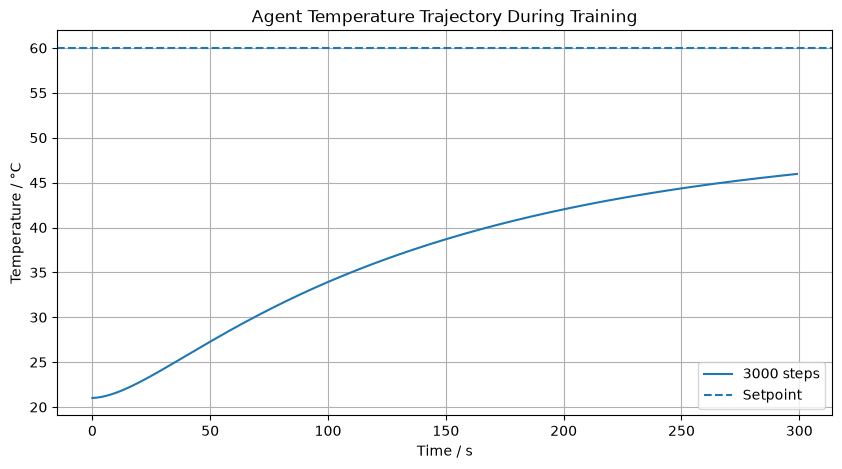

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 300      |
|    ep_rew_mean     | -68.8    |
| time/              |          |
|    episodes        | 12       |
|    fps             | 33       |
|    time_elapsed    | 106      |
|    total_timesteps | 3600     |
| train/             |          |
|    actor_loss      | -2.51    |
|    critic_loss     | 0.0164   |
|    ent_coef        | 0.349    |
|    ent_coef_loss   | -1.74    |
|    learning_rate   | 0.0003   |
|    n_updates       | 3499     |
---------------------------------


KeyboardInterrupt: 

In [6]:
model.learn(
    total_timesteps=300_000,
    callback=live_plot_callback,
    tb_log_name="SAC_TCLab"
)
model.save("./model_SAC_1")

In [ ]:
def find_latest_event_file(log_dir="./tensorboard_logs/"):
    event_files = []

    for root, dirs, files in os.walk(log_dir):
        for file in files:
            if "events.out.tfevents" in file:
                event_files.append(os.path.join(root, file))

    if len(event_files) == 0:
        raise FileNotFoundError("No TensorBoard event files found.")

    latest_file = max(event_files, key=os.path.getmtime)

    return latest_file


def plot_tensorboard_scalar(event_acc, tag):
    scalar_data = event_acc.Scalars(tag)

    steps = [x.step for x in scalar_data]
    values = [x.value for x in scalar_data]

    plt.figure(figsize=(10, 5))
    plt.plot(steps, values)
    plt.xlabel("Training steps")
    plt.ylabel(tag)
    plt.title(tag)
    plt.grid(True)
    plt.show()


event_file = find_latest_event_file(tensorboard_log)

print("Reading TensorBoard file:")
print(event_file)

event_acc = EventAccumulator(event_file)
event_acc.Reload()

print("Available TensorBoard scalar tags:")
print(event_acc.Tags()["scalars"])


# ============================================================
# Plot useful SAC training metrics
# Only plots tags that exist
# ============================================================

tags_to_plot = [
    "rollout/ep_rew_mean",
    "rollout/ep_len_mean",
    "train/actor_loss",
    "train/critic_loss",
    "train/ent_coef",
    "train/learning_rate"
]

available_tags = event_acc.Tags()["scalars"]

for tag in tags_to_plot:
    if tag in available_tags:
        plot_tensorboard_scalar(event_acc, tag)
    else:
        print(f"Skipping {tag} because it was not found.")